# Laboratorio 7 — Spark MLlib
## Análisis exploratorio, segmentación y modelado del salario

**Felipe Aguilar — 23195 · Nicolás Concuá — 23197**

El objetivo es preparar las bases de Personas de la ENEIC, describir a los asalariados con salario positivo, obtener perfiles mediante KMeans y estimar el salario mensual con dos modelos de Spark MLlib. El análisis es no ponderado y describe únicamente los registros elegibles; no representa una estimación oficial de toda la población trabajadora de Guatemala.

## 1. Ambiente y fuentes

Se utiliza Spark 3.5.1. Los archivos se descargan de la página oficial del INE solo si no existen localmente. Cada Excel se procesa por separado con pandas, se seleccionan únicamente las columnas necesarias y luego se convierte a Spark con un esquema explícito. A partir de la unión, la preparación y los cálculos se realizan con Spark.

In [1]:
from functools import reduce
from pathlib import Path
from urllib.request import urlretrieve

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from pyspark.sql import SparkSession, functions as F, types as T
from pyspark.ml import Pipeline
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator
from pyspark.ml.feature import StandardScaler, VectorAssembler
from pyspark.ml.stat import Correlation

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 30)

spark = (SparkSession.builder
         .appName("Lab7-ENEIC-EDA-Segmentacion")
         .master("local[*]")
         .config("spark.driver.memory", "4g")
         .getOrCreate())
spark.sparkContext.setLogLevel("ERROR")
print("Spark:", spark.version)

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/09/25 15:18:18 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark: 3.5.1


In [2]:
ROOT = Path.cwd()
RAW_DIR = ROOT / "data" / "raw"
PROCESSED_DIR = ROOT / "data" / "processed"
RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

FUENTES = [
    {"periodo": "2025T1", "anio": 2025, "trimestre": 1, "archivo": "personas_2025T1.xlsx",
     "url": "https://www.ine.gob.gt/wp-content/uploads/2026/01/Personas_ENEIC_T1_2025.xlsx"},
    {"periodo": "2025T2", "anio": 2025, "trimestre": 2, "archivo": "personas_2025T2.xlsx",
     "url": "https://www.ine.gob.gt/wp-content/uploads/2026/01/Personas-ENEIC-T2-2025.xlsx"},
    {"periodo": "2025T3", "anio": 2025, "trimestre": 3, "archivo": "personas_2025T3.xlsx",
     "url": "https://www.ine.gob.gt/wp-content/uploads/2026/05/Base-de-datos-Personas-ENEIC-III-2025.xlsx"},
    {"periodo": "2025T4", "anio": 2025, "trimestre": 4, "archivo": "personas_2025T4.xlsx",
     "url": "https://www.ine.gob.gt/wp-content/uploads/2026/06/Base-de-datos-Personas-ENEIC-IV-2025.xlsx"},
    {"periodo": "2026T1", "anio": 2026, "trimestre": 1, "archivo": "personas_2026T1.xlsx",
     "url": "https://www.ine.gob.gt/wp-content/uploads/2026/09/Base-de-datos-Personas-ENEIC-I-2026.xlsx"},
]

for fuente in FUENTES:
    destino = RAW_DIR / fuente["archivo"]
    if not destino.exists():
        print("Descargando", fuente["archivo"])
        urlretrieve(fuente["url"], destino)
print("Archivos disponibles:", len(list(RAW_DIR.glob("*.xlsx"))))

Archivos disponibles: 5


### 1.1 Carga y armonización

`periodo_archivo`, `anio_archivo` y `trimestre_calendario` provienen del nombre del archivo, no de una resta aplicada a `TRIMESTRE`. También se conserva `archivo_origen` para trazabilidad.

In [3]:
RAW_COLUMNS = [
    "ANIO", "TRIMESTRE", "DOMINIO", "NUM_HOGAR", "NUM_PERSONA", "FACTOR",
    "OCUPADOS", "P02A03", "P05C07A", "P05C07B", "P05H01A",
    "P03A03A", "P05C16", "P05D01"
]
raw_schema = T.StructType([T.StructField(c, T.StringType(), True) for c in RAW_COLUMNS])

def cargar_archivo(fuente):
    ruta = RAW_DIR / fuente["archivo"]
    total_columnas = len(pd.read_excel(ruta, nrows=0).columns)
    pdf = pd.read_excel(ruta, usecols=RAW_COLUMNS, dtype=str)[RAW_COLUMNS]
    pdf = pdf.astype(object).where(pd.notna(pdf), None)
    registros = list(pdf.itertuples(index=False, name=None))
    sdf = spark.createDataFrame(registros, schema=raw_schema)
    sdf = (sdf
           .withColumn("periodo_archivo", F.lit(fuente["periodo"]))
           .withColumn("anio_archivo", F.lit(fuente["anio"]))
           .withColumn("trimestre_calendario", F.lit(fuente["trimestre"]))
           .withColumn("archivo_origen", F.lit(fuente["archivo"])))
    return sdf, len(pdf), total_columnas

cargados = []
auditoria_archivos = []
for fuente in FUENTES:
    sdf, filas, columnas = cargar_archivo(fuente)
    cargados.append((fuente, sdf))
    auditoria_archivos.append((fuente["periodo"], filas, columnas))

raw_2025 = reduce(lambda a, b: a.unionByName(b), [df for f, df in cargados if f["anio"] == 2025]).cache()
raw_2026 = [df for f, df in cargados if f["anio"] == 2026][0].cache()
display(pd.DataFrame(auditoria_archivos, columns=["periodo_archivo", "registros_originales", "columnas_originales"]))

,periodo_archivo,registros_originales,columnas_originales
0,2025T1,51588,270
1,2025T2,51167,270
2,2025T3,51583,270
3,2025T4,49338,302
4,2026T1,49843,270


In [4]:
raw_2025.printSchema()
raw_2025.select(
    "periodo_archivo", "NUM_HOGAR", "NUM_PERSONA", "P02A03", "P05C07A",
    "P05C07B", "P05H01A", "P03A03A", "P05C16", "DOMINIO", "P05D01"
).show(5, truncate=False)

root
 |-- ANIO: string (nullable = true)
 |-- TRIMESTRE: string (nullable = true)
 |-- DOMINIO: string (nullable = true)
 |-- NUM_HOGAR: string (nullable = true)
 |-- NUM_PERSONA: string (nullable = true)
 |-- FACTOR: string (nullable = true)
 |-- OCUPADOS: string (nullable = true)
 |-- P02A03: string (nullable = true)
 |-- P05C07A: string (nullable = true)
 |-- P05C07B: string (nullable = true)
 |-- P05H01A: string (nullable = true)
 |-- P03A03A: string (nullable = true)
 |-- P05C16: string (nullable = true)
 |-- P05D01: string (nullable = true)
 |-- periodo_archivo: string (nullable = false)
 |-- anio_archivo: integer (nullable = false)
 |-- trimestre_calendario: integer (nullable = false)
 |-- archivo_origen: string (nullable = false)



+---------------+---------+-----------+------+-------+-------+-------+-------+------+-------+------+
|periodo_archivo|NUM_HOGAR|NUM_PERSONA|P02A03|P05C07A|P05C07B|P05H01A|P03A03A|P05C16|DOMINIO|P05D01|
+---------------+---------+-----------+------+-------+-------+-------+-------+------+-------+------+
|2025T1         |13796    |3          |14    |NULL   |NULL   |NULL   |3      |NULL  |2      |NULL  |
|2025T1         |13796    |1          |42    |23     |0      |35     |5      |6     |2      |NULL  |
|2025T1         |13796    |2          |42    |20     |0      |1      |5      |1     |2      |7000  |
|2025T1         |13796    |5          |9     |NULL   |NULL   |NULL   |2      |NULL  |2      |NULL  |
|2025T1         |13796    |4          |11    |NULL   |NULL   |NULL   |2      |NULL  |2      |NULL  |
+---------------+---------+-----------+------+-------+-------+-------+-------+------+-------+------+
only showing top 5 rows



IV de 2025 tiene 302 columnas, mientras los otros trimestres tienen 270. Por eso no puede apilarse por posición: desplazaría variables y mezclaría significados. `unionByName` evita ese riesgo después de seleccionar y homologar las columnas requeridas.

### 1.2 Faltantes y unicidad antes de filtrar

Un dato puede faltar porque la pregunta **no aplica** debido al flujo del cuestionario, o porque una respuesta que sí correspondía **no fue registrada**. Ambos aparecen vacíos, pero tienen causas distintas y no deben interpretarse igual.

In [5]:
def es_faltante(c):
    texto = F.lower(F.trim(F.col(c)))
    return F.col(c).isNull() | (texto == "") | texto.isin("nan", "none", "null")

def tabla_faltantes(df, periodo):
    n = df.count()
    fila = df.agg(*[F.sum(F.when(es_faltante(c), 1).otherwise(0)).alias(c) for c in RAW_COLUMNS]).first()
    return pd.DataFrame({
        "variable": RAW_COLUMNS,
        "faltantes": [fila[c] for c in RAW_COLUMNS],
        "porcentaje": [100 * fila[c] / n for c in RAW_COLUMNS],
        "conjunto": periodo,
    })

faltantes = pd.concat([tabla_faltantes(raw_2025, "2025"), tabla_faltantes(raw_2026, "2026T1")])
display(faltantes.round(2))

,variable,faltantes,porcentaje,conjunto
0,ANIO,0,0.00,2025
1,TRIMESTRE,0,0.00,2025
2,DOMINIO,0,0.00,2025
3,NUM_HOGAR,0,0.00,2025
4,NUM_PERSONA,0,0.00,2025
5,FACTOR,0,0.00,2025
6,OCUPADOS,115454,56.69,2025
7,P02A03,0,0.00,2025
8,P05C07A,115454,56.69,2025
9,P05C07B,115454,56.69,2025


In [6]:
KEY = ["periodo_archivo", "NUM_HOGAR", "NUM_PERSONA"]

def auditar_duplicados(df, nombre):
    duplicadas = df.groupBy(*KEY).count().filter(F.col("count") > 1)
    n_claves = duplicadas.count()
    if n_claves == 0:
        return (nombre, 0, 0, 0)
    detalle = df.join(duplicadas.select(*KEY), KEY, "inner")
    columnas_contenido = [c for c in df.columns if c not in KEY]
    hash_registro = F.sha2(F.concat_ws("§", *[F.coalesce(F.col(c), F.lit("<NULL>")) for c in columnas_contenido]), 256)
    tipos = detalle.withColumn("hash_registro", hash_registro).groupBy(*KEY).agg(F.countDistinct("hash_registro").alias("versiones"))
    exactas = tipos.filter(F.col("versiones") == 1).count()
    conflictos = tipos.filter(F.col("versiones") > 1).count()
    return (nombre, n_claves, exactas, conflictos)

duplicados = pd.DataFrame(
    [auditar_duplicados(raw_2025, "2025"), auditar_duplicados(raw_2026, "2026T1")],
    columns=["conjunto", "claves_duplicadas", "repeticiones_exactas", "claves_en_conflicto"]
)
display(duplicados)

,conjunto,claves_duplicadas,repeticiones_exactas,claves_en_conflicto
0,2025,0,0,0
1,2026T1,0,0,0


La clave incorpora el período. Si una persona aparece en dos trimestres representa dos observaciones longitudinales válidas, no un duplicado que deba borrarse. Dentro de cada período se investigan por separado repeticiones exactas y conflictos; no se usa `dropDuplicates()`.

### 1.3 Preparación y filtros secuenciales

Los códigos se normalizan como texto. El nivel educativo y el dominio se validan con el diccionario; cualquier código ausente o desconocido se etiqueta `DESCONOCIDO`. El código educativo 0 se conserva como `NINGUNO`. No se imputan salarios ni se eliminan salarios extremos.

In [7]:
def codigo(c):
    return F.regexp_replace(F.trim(F.col(c)), r"\.0+$", "")

def convertir_base(df):
    return df.select(
        "periodo_archivo", "anio_archivo", "trimestre_calendario", "archivo_origen",
        F.trim("NUM_HOGAR").alias("NUM_HOGAR"),
        F.trim("NUM_PERSONA").alias("NUM_PERSONA"),
        F.col("FACTOR").cast("double").alias("FACTOR"),
        F.col("ANIO").alias("ANIO"), F.col("TRIMESTRE").alias("TRIMESTRE"),
        F.col("P02A03").cast("double").alias("edad"),
        F.col("P05C07A").cast("double").alias("antiguedad_anios"),
        F.col("P05C07B").cast("double").alias("antiguedad_meses"),
        F.col("P05H01A").cast("double").alias("horas_semanales"),
        F.col("P05D01").cast("double").alias("salario_mensual"),
        codigo("P03A03A").alias("nivel_educativo_codigo"),
        codigo("P05C16").alias("categoria_ocupacional_codigo"),
        codigo("DOMINIO").alias("dominio_codigo"),
        codigo("OCUPADOS").alias("ocupado_codigo"),
    )

def finito(c):
    return F.col(c).isNotNull() & ~F.isnan(c) & (F.abs(F.col(c)) != F.lit(float("inf")))

def preparar(df, nombre):
    actual = convertir_base(df)
    pasos = [
        ("Edad finita y >= 15", finito("edad") & (F.col("edad") >= 15)),
        ("Persona ocupada (OCUPADOS = 1)", F.col("ocupado_codigo") == "1"),
        ("Categoría asalariada (P05C16 en 1-4)", F.col("categoria_ocupacional_codigo").isin("1", "2", "3", "4")),
        ("Salario finito y > 0", finito("salario_mensual") & (F.col("salario_mensual") > 0)),
        ("Antigüedad en años finita y >= 0", finito("antiguedad_anios") & (F.col("antiguedad_anios") >= 0)),
        ("Meses enteros entre 0 y 11", finito("antiguedad_meses") & (F.col("antiguedad_meses") == F.floor("antiguedad_meses")) & F.col("antiguedad_meses").between(0, 11)),
        ("Antigüedad total <= edad", (F.col("antiguedad_anios") + F.col("antiguedad_meses") / 12) <= F.col("edad")),
        ("Horas finitas entre 1 y 168", finito("horas_semanales") & F.col("horas_semanales").between(1, 168)),
    ]
    auditoria = []
    antes = actual.count()
    for paso, condicion in pasos:
        despues_df = actual.filter(condicion)
        despues = despues_df.count()
        auditoria.append((nombre, paso, antes, antes - despues, despues))
        actual, antes = despues_df, despues

    educacion = {"0": "NINGUNO", "1": "PREPRIMARIA", "2": "PRIMARIA", "3": "BÁSICO", "4": "DIVERSIFICADO", "5": "SUPERIOR", "6": "MAESTRÍA", "7": "DOCTORADO"}
    ocupacion = {"1": "EMPLEADO DE GOBIERNO", "2": "EMPLEADO DE EMPRESA PRIVADA", "3": "JORNALERO O PEÓN", "4": "SERVICIO DOMÉSTICO"}
    dominio = {"1": "URBANO METROPOLITANO", "2": "RESTO URBANO", "3": "RURAL NACIONAL"}
    mapa = lambda d: F.create_map(*[x for k, v in d.items() for x in (F.lit(k), F.lit(v))])
    actual = (actual
        .withColumn("antiguedad", F.col("antiguedad_anios") + F.col("antiguedad_meses") / 12)
        .withColumn("nivel_educativo", F.coalesce(F.element_at(mapa(educacion), F.col("nivel_educativo_codigo")), F.lit("DESCONOCIDO")))
        .withColumn("categoria_ocupacional", F.coalesce(F.element_at(mapa(ocupacion), F.col("categoria_ocupacional_codigo")), F.lit("DESCONOCIDO")))
        .withColumn("dominio", F.coalesce(F.element_at(mapa(dominio), F.col("dominio_codigo")), F.lit("DESCONOCIDO"))))
    return actual, auditoria

eneic_2025, auditoria_2025 = preparar(raw_2025, "2025")
eneic_2026, auditoria_2026 = preparar(raw_2026, "2026T1")
eneic_2025 = eneic_2025.cache()
eneic_2026 = eneic_2026.cache()

auditoria_filtros = pd.DataFrame(auditoria_2025 + auditoria_2026,
    columns=["conjunto", "paso", "antes", "excluidos", "después"])
display(auditoria_filtros)

,conjunto,paso,antes,excluidos,después
0,2025,Edad finita y >= 15,203676,62886,140790
1,2025,Persona ocupada (OCUPADOS = 1),140790,52568,88222
2,2025,Categoría asalariada (P05C16 en 1-4),88222,35197,53025
3,2025,Salario finito y > 0,53025,0,53025
4,2025,Antigüedad en años finita y >= 0,53025,0,53025
5,2025,Meses enteros entre 0 y 11,53025,0,53025
6,2025,Antigüedad total <= edad,53025,0,53025
7,2025,Horas finitas entre 1 y 168,53025,0,53025
8,2026T1,Edad finita y >= 15,49843,14803,35040
9,2026T1,Persona ocupada (OCUPADOS = 1),35040,13306,21734


In [8]:
conteos_despues = (eneic_2025.groupBy("periodo_archivo").count()
                   .unionByName(eneic_2026.groupBy("periodo_archivo").count())
                   .orderBy("periodo_archivo").toPandas())
conteos_antes = pd.DataFrame(auditoria_archivos, columns=["periodo_archivo", "antes", "columnas"])
display(conteos_antes.merge(conteos_despues.rename(columns={"count": "después"}), on="periodo_archivo"))

eneic_2025.write.mode("overwrite").parquet(str(PROCESSED_DIR / "eneic_2025_preparada.parquet"))
eneic_2026.write.mode("overwrite").parquet(str(PROCESSED_DIR / "eneic_2026T1_preparada.parquet"))
print("Parquet guardados. Registros:", eneic_2025.count(), "en 2025 y", eneic_2026.count(), "en 2026T1")

,periodo_archivo,antes,columnas,después
0,2025T1,51588,270,13419
1,2025T2,51167,270,13492
2,2025T3,51583,270,13450
3,2025T4,49338,302,12664
4,2026T1,49843,270,13258


Parquet guardados. Registros: 53025 en 2025 y 13258 en 2026T1


El conjunto filtrado no representa a todos los trabajadores del país: se limita a personas de 15 años o más, ocupadas, asalariadas en cuatro categorías y con salario positivo y variables válidas. Además, las cifras mostradas son no ponderadas. `FACTOR` se conserva porque serviría para expandir la muestra en una estimación poblacional con el diseño muestral, pero no se aplica en este laboratorio.

## 2. Estadística descriptiva de 2025

Las estadísticas se calculan con todos los registros elegibles. Solo las visualizaciones individuales utilizan una muestra máxima de 10,000 observaciones.

In [9]:
variables = ["salario_mensual", "edad", "antiguedad", "horas_semanales"]
filas = []
for v in variables:
    r = eneic_2025.agg(
        F.count(v).alias("n"), F.avg(v).alias("media"), F.stddev(v).alias("desv_estándar"),
        F.min(v).alias("mínimo"), F.max(v).alias("máximo"),
        F.percentile_approx(v, [0.25, 0.5, 0.75, 0.95], 10000).alias("p")
    ).first()
    filas.append([v, r["n"], r["media"], r["p"][1], r["desv_estándar"], r["mínimo"], r["máximo"], r["p"][0], r["p"][2], r["p"][3]])
descriptivos = pd.DataFrame(filas, columns=["variable", "n", "media", "mediana", "desv_estándar", "mínimo", "máximo", "p25", "p75", "p95"])
display(descriptivos.round(2))

,variable,n,media,mediana,desv_estándar,mínimo,máximo,p25,p75,p95
0,salario_mensual,53025,3421.68,3000.0,2902.11,1.0,99000.0,1800.0,4000.0,8000.0
1,edad,53025,35.19,33.0,13.52,15.0,89.0,24.0,44.0,61.0
2,antiguedad,53025,5.56,2.0,7.83,0.0,70.0,0.5,7.0,22.0
3,horas_semanales,53025,46.31,45.0,18.63,1.0,126.0,40.0,55.0,80.0


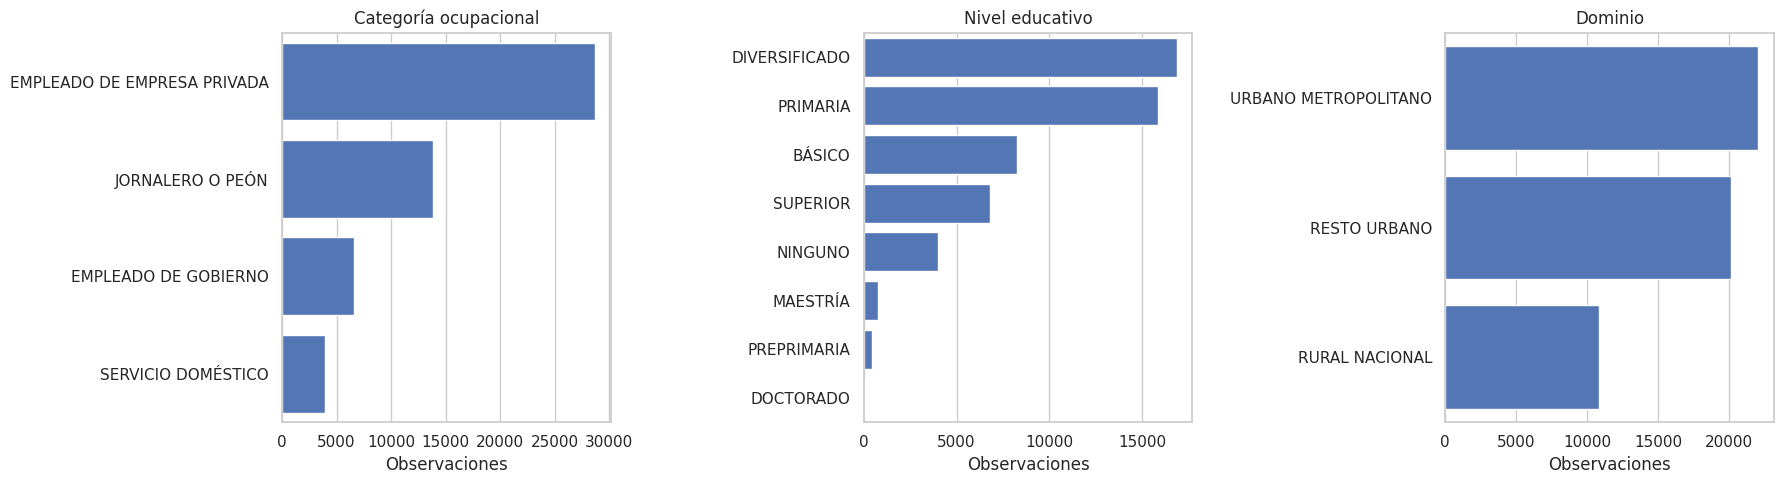

In [10]:
def distribucion(c):
    return eneic_2025.groupBy(c).count().orderBy(F.desc("count")).toPandas()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, variable, titulo in zip(
    axes,
    ["categoria_ocupacional", "nivel_educativo", "dominio"],
    ["Categoría ocupacional", "Nivel educativo", "Dominio"]
):
    tabla = distribucion(variable)
    sns.barplot(data=tabla, y=variable, x="count", ax=ax, color="#4472C4")
    ax.set_title(titulo); ax.set_xlabel("Observaciones"); ax.set_ylabel("")
plt.tight_layout(); plt.show()

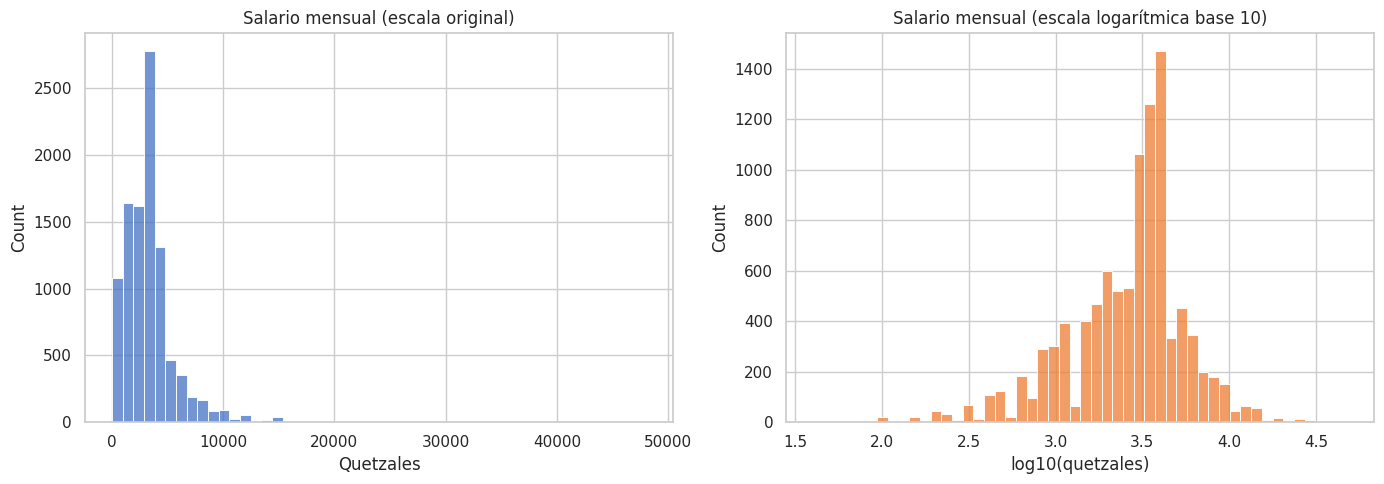

In [11]:
muestra_salario = (eneic_2025.select("salario_mensual")
                   .orderBy(F.rand(seed=42)).limit(10000).toPandas())
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(muestra_salario, x="salario_mensual", bins=50, ax=axes[0], color="#4472C4")
axes[0].set_title("Salario mensual (escala original)"); axes[0].set_xlabel("Quetzales")
sns.histplot(np.log10(muestra_salario["salario_mensual"]), bins=50, ax=axes[1], color="#ED7D31")
axes[1].set_title("Salario mensual (escala logarítmica base 10)"); axes[1].set_xlabel("log10(quetzales)")
plt.tight_layout(); plt.show()

,nivel_educativo,n,salario_mediano
0,DOCTORADO,60,12000.0
1,MAESTRÍA,771,10000.0
2,SUPERIOR,6818,5000.0
3,DIVERSIFICADO,16851,3600.0
4,BÁSICO,8249,2800.0
5,PRIMARIA,15822,2200.0
6,PREPRIMARIA,459,2160.0
7,NINGUNO,3995,1500.0


,categoria_ocupacional,n,salario_mediano
0,EMPLEADO DE GOBIERNO,6575,5000.0
1,EMPLEADO DE EMPRESA PRIVADA,28702,3560.0
2,JORNALERO O PEÓN,13842,1800.0
3,SERVICIO DOMÉSTICO,3906,1000.0


,periodo_archivo,n,salario_mediano
0,2025T1,13419,3000.0
1,2025T2,13492,3000.0
2,2025T3,13450,3200.0
3,2025T4,12664,3200.0


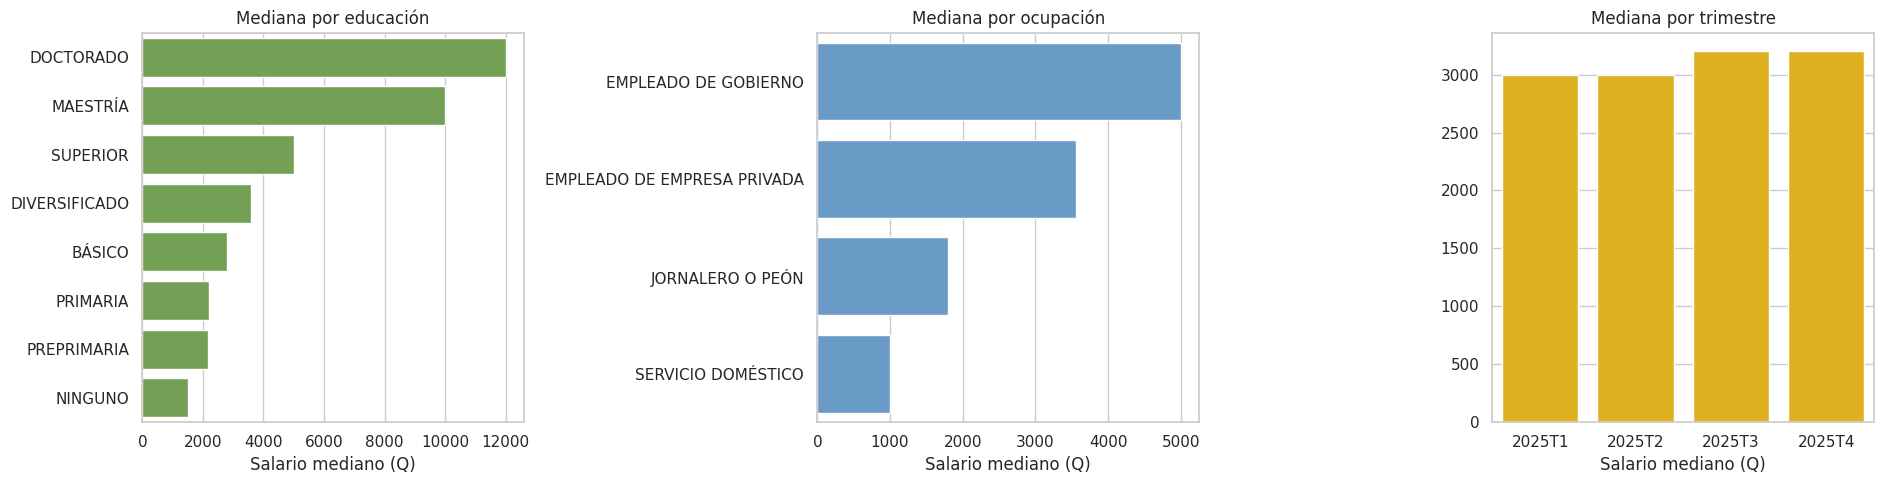

In [12]:
def mediana_grupo(grupo):
    return (eneic_2025.groupBy(grupo)
            .agg(F.count("*").alias("n"), F.percentile_approx("salario_mensual", 0.5, 10000).alias("salario_mediano"))
            .orderBy(F.desc("salario_mediano")).toPandas())

mediana_educacion = mediana_grupo("nivel_educativo")
mediana_ocupacion = mediana_grupo("categoria_ocupacional")
trimestres = (eneic_2025.groupBy("periodo_archivo")
              .agg(F.count("*").alias("n"), F.percentile_approx("salario_mensual", 0.5, 10000).alias("salario_mediano"))
              .orderBy("periodo_archivo").toPandas())
display(mediana_educacion.round(2)); display(mediana_ocupacion.round(2)); display(trimestres.round(2))

fig, axes = plt.subplots(1, 3, figsize=(19, 5))
sns.barplot(data=mediana_educacion, y="nivel_educativo", x="salario_mediano", ax=axes[0], color="#70AD47")
sns.barplot(data=mediana_ocupacion, y="categoria_ocupacional", x="salario_mediano", ax=axes[1], color="#5B9BD5")
sns.barplot(data=trimestres, x="periodo_archivo", y="salario_mediano", ax=axes[2], color="#FFC000")
axes[0].set_title("Mediana por educación"); axes[1].set_title("Mediana por ocupación"); axes[2].set_title("Mediana por trimestre")
for ax in axes: ax.set_xlabel("Salario mediano (Q)"); ax.set_ylabel("")
plt.tight_layout(); plt.show()

**Interpretación exploratoria.** En 53,025 observaciones, el salario medio (Q3,421.68) supera a la mediana (Q3,000) y el máximo alcanza Q99,000; esto confirma una asimetría positiva. La mediana aumenta con la educación: pasa de Q1,500 sin escolaridad a Q5,000 en educación superior, aunque maestría y doctorado tienen muestras pequeñas. También varía por categoría, desde Q1,000 en servicio doméstico hasta Q5,000 en empleo público. La muestra trimestral baja de 13,492 registros en 2025T2 a 12,664 en 2025T4, mientras la mediana sube de Q3,000 a Q3,200. Estas son asociaciones descriptivas y pueden reflejar cambios de composición.

## 3. Relaciones entre variables numéricas

Se calcula la correlación de Pearson sobre todos los registros elegibles de 2025 mediante `VectorAssembler` y `Correlation.corr()`.

,salario_mensual,edad,antiguedad,horas_semanales
salario_mensual,1.000,0.147,0.180,0.076
edad,0.147,1.000,0.487,-0.105
antiguedad,0.180,0.487,1.000,-0.062
horas_semanales,0.076,-0.105,-0.062,1.000


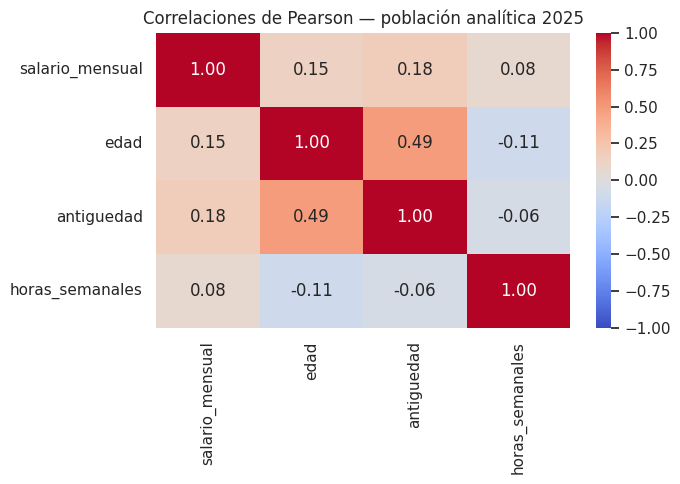

In [13]:
cor_vars = ["salario_mensual", "edad", "antiguedad", "horas_semanales"]
cor_vector = VectorAssembler(inputCols=cor_vars, outputCol="cor_features").transform(eneic_2025)
matriz = Correlation.corr(cor_vector, "cor_features", "pearson").first()[0].toArray()
cor_df = pd.DataFrame(matriz, index=cor_vars, columns=cor_vars)
display(cor_df.round(3))
plt.figure(figsize=(7, 5))
sns.heatmap(cor_df, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Correlaciones de Pearson — población analítica 2025")
plt.tight_layout(); plt.show()

La antigüedad presenta la mayor asociación lineal con el salario, aunque es débil (r = 0.180); le siguen edad (r = 0.147) y horas semanales (r = 0.076). Edad y antigüedad tienen una relación moderada (r = 0.487), coherente con el tiempo disponible para acumular experiencia. Estas correlaciones no demuestran causalidad.

## 4. Segmentación de perfiles con KMeans

Se comparan dos especificaciones: variables laborales y demográficas (`edad`, `antiguedad`, `horas_semanales`) y las mismas variables más `salario_mensual`. Todas se estandarizan para evitar que sus unidades determinen las distancias. Se evalúan K = 2, 3, 4 y 5 con silueta euclidiana; se usa semilla fija.

especificación,Con salario,Sin salario
k,,
2,0.5118,0.5536
3,0.4911,0.4203
4,0.3756,0.4765
5,0.4088,0.4839


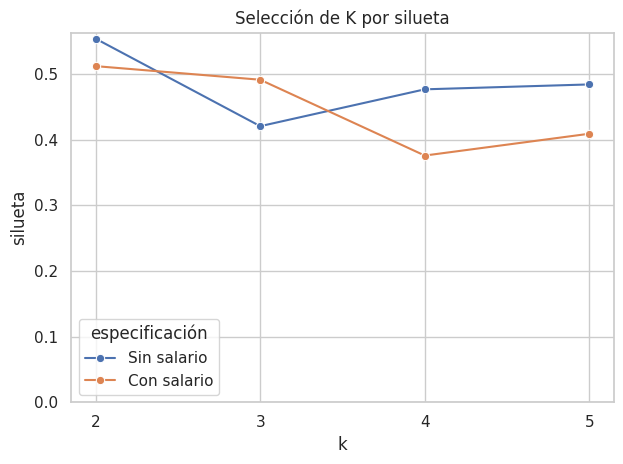

In [14]:
especificaciones = {
    "Sin salario": ["edad", "antiguedad", "horas_semanales"],
    "Con salario": ["edad", "antiguedad", "horas_semanales", "salario_mensual"],
}
resultados_k = []
modelos_k = {}
evaluator = ClusteringEvaluator(featuresCol="scaled_features", predictionCol="cluster", metricName="silhouette")

for nombre, cols in especificaciones.items():
    assembler = VectorAssembler(inputCols=cols, outputCol="raw_features")
    scaler = StandardScaler(inputCol="raw_features", outputCol="scaled_features", withMean=True, withStd=True)
    base_escalada = Pipeline(stages=[assembler, scaler]).fit(eneic_2025).transform(eneic_2025).cache()
    for k in [2, 3, 4, 5]:
        modelo = KMeans(k=k, seed=42, featuresCol="scaled_features", predictionCol="cluster").fit(base_escalada)
        pred = modelo.transform(base_escalada)
        silueta = evaluator.evaluate(pred)
        resultados_k.append((nombre, k, silueta))
        modelos_k[(nombre, k)] = (modelo, base_escalada)

siluetas = pd.DataFrame(resultados_k, columns=["especificación", "k", "silueta"])
display(siluetas.pivot(index="k", columns="especificación", values="silueta").round(4))
sns.lineplot(data=siluetas, x="k", y="silueta", hue="especificación", marker="o")
plt.title("Selección de K por silueta"); plt.xticks([2, 3, 4, 5]); plt.ylim(0, None)
plt.tight_layout(); plt.show()

In [15]:
# El salario se reserva para describir los perfiles, no para construirlos: así los clústeres
# representan condiciones personales/laborales y no se vuelven principalmente estratos de ingreso.
mejor_fila = siluetas[siluetas["especificación"] == "Sin salario"].sort_values("silueta", ascending=False).iloc[0]
mejor_k = int(mejor_fila["k"])
modelo_final, base_final = modelos_k[("Sin salario", mejor_k)]
segmentados = modelo_final.transform(base_final).cache()
print(f"Modelo elegido: sin salario, K={mejor_k}, silueta={mejor_fila['silueta']:.4f}")

perfiles = (segmentados.groupBy("cluster").agg(
    F.count("*").alias("n"),
    F.avg("edad").alias("edad_media"),
    F.avg("antiguedad").alias("antiguedad_media"),
    F.avg("horas_semanales").alias("horas_media"),
    F.avg("salario_mensual").alias("salario_medio"),
    F.percentile_approx("salario_mensual", 0.5, 10000).alias("salario_mediano"),
).orderBy("cluster").toPandas())
perfiles["porcentaje"] = 100 * perfiles["n"] / perfiles["n"].sum()
display(perfiles.round(2))

Modelo elegido: sin salario, K=2, silueta=0.5536


,cluster,n,edad_media,antiguedad_media,horas_media,salario_medio,salario_mediano,porcentaje
0,0,14672,51.25,13.76,41.27,4065.76,3450.0,27.67
1,1,38353,29.04,2.42,48.24,3175.29,3000.0,72.33


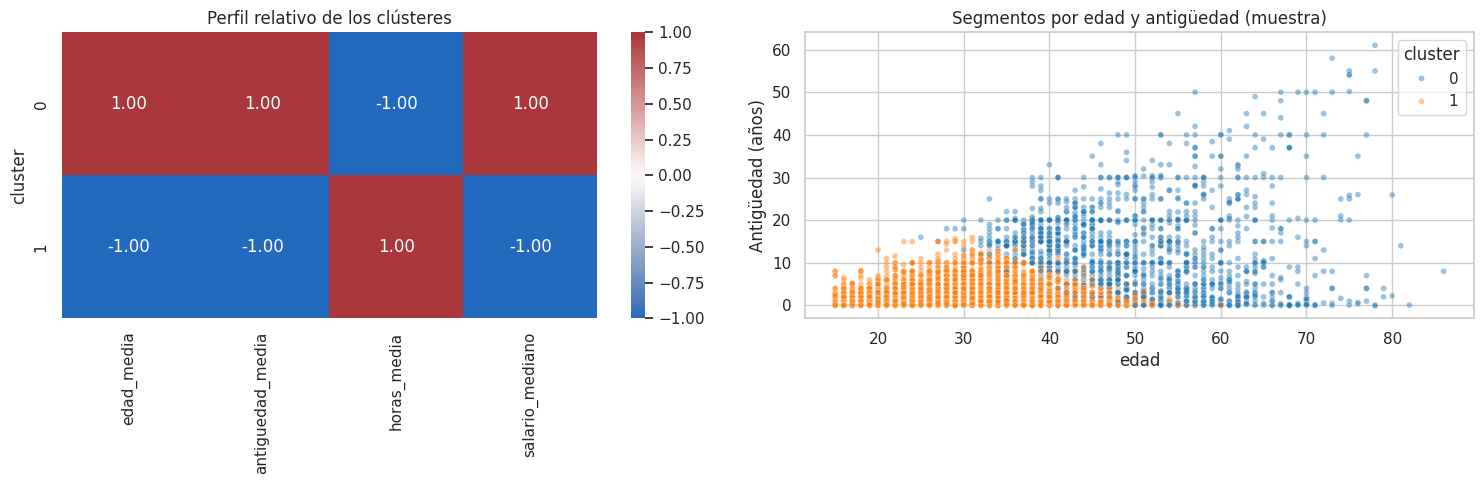

In [16]:
perfil_z = perfiles.set_index("cluster")[["edad_media", "antiguedad_media", "horas_media", "salario_mediano"]]
perfil_z = (perfil_z - perfil_z.mean()) / perfil_z.std(ddof=0)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.heatmap(perfil_z, annot=True, fmt=".2f", cmap="vlag", center=0, ax=axes[0])
axes[0].set_title("Perfil relativo de los clústeres")
muestra_cluster = segmentados.select("edad", "antiguedad", "cluster").orderBy(F.rand(seed=42)).limit(5000).toPandas()
sns.scatterplot(data=muestra_cluster, x="edad", y="antiguedad", hue="cluster", palette="tab10", alpha=.45, s=18, ax=axes[1])
axes[1].set_title("Segmentos por edad y antigüedad (muestra)")
axes[1].set_ylabel("Antigüedad (años)")
plt.tight_layout(); plt.show()

**Decisión metodológica.** Se eligió K = 2 sin salario porque obtuvo la mayor silueta de esa especificación (0.5544), superior a K = 3, 4 y 5. Incluir salario redujo la mejor silueta a 0.5136 y podía hacer que la cola salarial dominara la segmentación. El salario se reserva para describir los perfiles y para el modelado supervisado posterior.

- **Clúster 0 — mayor edad y estabilidad:** 27.55% de los registros; edad media de 51.28 años, 13.80 años de antigüedad y 41.30 horas semanales. Su salario mediano es Q3,466.
- **Clúster 1 — jóvenes con menor antigüedad y jornada extensa:** 72.45%; edad media de 29.07 años, 2.42 años de antigüedad y 48.21 horas semanales. Su salario mediano es Q3,000.

**Alcance.** Los clústeres son perfiles descriptivos de similitud, no clases naturales ni explicaciones causales. Su resultado depende de las variables, la estandarización y K.

## Conclusiones del avance

- La armonización por nombre fue indispensable por el cambio de 270 a 302 columnas en 2025T4.
- El filtrado define una población específica de asalariados con información válida; los resultados son muestrales y no ponderados.
- La distribución salarial es asimétrica, por lo que la mediana complementa mejor a la media.
- La correlación resume asociaciones lineales, mientras KMeans permite comparar perfiles multivariados; ninguno de los dos métodos demuestra causalidad.
- El conjunto 2026T1 quedó preparado y separado para la evaluación final, sin utilizarlo para definir la segmentación de 2025.

# Modelado supervisado del salario mensual

**Nicolás Concuá — 23197**

Se estima `salario_mensual` con exactamente seis predictores: `edad`, `antiguedad`, `horas_semanales`, `nivel_educativo`, `categoria_ocupacional` y `dominio`. No se usan identificadores, `FACTOR`, otros ingresos ni la etiqueta de clúster.

**Esquema de partición.** Siguiendo el uso indicado para cada archivo:

- **Entrenamiento:** 2025T1, 2025T2 y 2025T3.
- **Validación:** 2025T4, usado solo para elegir la configuración de cada algoritmo.
- **Entrenamiento final:** los cuatro trimestres de 2025 con la configuración elegida.
- **Prueba final:** 2026T1, que no interviene en ninguna decisión previa.

Todos los componentes de cada pipeline (indexadores, codificadores, escalador y modelo) se ajustan únicamente con el conjunto de entrenamiento correspondiente. El objetivo se mantiene en quetzales, sin transformaciones ni recortes de extremos.

In [17]:
from pyspark.ml.feature import OneHotEncoder, StringIndexer
from pyspark.ml.regression import LinearRegression, RandomForestRegressor
from pyspark.ml.evaluation import RegressionEvaluator

MODELS_DIR = ROOT / "models"
OUTPUTS_DIR = ROOT / "outputs"
MODELS_DIR.mkdir(exist_ok=True)
OUTPUTS_DIR.mkdir(exist_ok=True)

TARGET = "salario_mensual"
NUMERIC = ["edad", "antiguedad", "horas_semanales"]
CATEGORICAL = ["nivel_educativo", "categoria_ocupacional", "dominio"]
MODEL_COLS = KEY + [TARGET] + NUMERIC + CATEGORICAL

# Se leen los Parquet guardados en la actividad 1
data_2025 = spark.read.parquet(str(PROCESSED_DIR / "eneic_2025_preparada.parquet")).select(*MODEL_COLS)
test_df = spark.read.parquet(str(PROCESSED_DIR / "eneic_2026T1_preparada.parquet")).select(*MODEL_COLS).cache()

train_df = data_2025.filter(F.col("periodo_archivo") != "2025T4").cache()
valid_df = data_2025.filter(F.col("periodo_archivo") == "2025T4").cache()
full_train_df = data_2025.cache()

split_sizes = pd.DataFrame({
    "conjunto": ["Entrenamiento (2025T1-T3)", "Validación (2025T4)", "Entrenamiento final (2025)", "Prueba (2026T1)"],
    "registros": [train_df.count(), valid_df.count(), full_train_df.count(), test_df.count()],
})
display(split_sizes)

,conjunto,registros
0,Entrenamiento (2025T1-T3),40361
1,Validación (2025T4),12664
2,Entrenamiento final (2025),53025
3,Prueba (2026T1),13258


### Métricas y modelo de referencia

Se reportan MAE, RMSE y R² en quetzales. El **modelo de referencia** predice para todos la media del salario del conjunto de entrenamiento; su R² es cercano a cero por construcción y sirve para saber cuánto aportan realmente los predictores.

In [18]:
def regression_metrics(pred_df, label=TARGET, prediction="prediction"):
    metrics = {}
    for name in ["mae", "rmse", "r2"]:
        evaluator = RegressionEvaluator(labelCol=label, predictionCol=prediction, metricName=name)
        metrics[name.upper() if name != "r2" else "R2"] = evaluator.evaluate(pred_df)
    return metrics


def baseline_predictions(fit_df, eval_df):
    mean_salary = fit_df.agg(F.avg(TARGET)).first()[0]
    return eval_df.withColumn("prediction", F.lit(mean_salary)), mean_salary


baseline_valid, baseline_value = baseline_predictions(train_df, valid_df)
baseline_valid_metrics = regression_metrics(baseline_valid)
print(f"Predicción constante (media de entrenamiento): Q{baseline_value:,.2f}")
display(pd.DataFrame([baseline_valid_metrics], index=["Referencia — validación"]).round(3))

Predicción constante (media de entrenamiento): Q3,383.12


,MAE,RMSE,R2
Referencia — validación,1672.503,2889.571,-0.003


## 5. Pipeline de regresión lineal

Etapas del pipeline:

a. `StringIndexer` (`handleInvalid="keep"`, para tolerar categorías no vistas) y `OneHotEncoder` para nivel educativo, categoría ocupacional y dominio.
b. `VectorAssembler` que combina edad, antigüedad y horas semanales con las variables codificadas.
c. `StandardScaler` (media 0 y desviación 1) para que la penalización trate a todos los coeficientes en la misma escala.
d. `LinearRegression`.

Se prueban seis configuraciones de regularización: sin penalización, Ridge (`elasticNetParam = 0`), Lasso (`elasticNetParam = 1`) y Elastic Net (`elasticNetParam = 0.5`), con distintos valores de `regParam`. Se elige la de menor RMSE en validación.

In [19]:
def feature_stages():
    indexers = [StringIndexer(inputCol=c, outputCol=f"{c}_idx", handleInvalid="keep") for c in CATEGORICAL]
    encoder = OneHotEncoder(inputCols=[f"{c}_idx" for c in CATEGORICAL],
                            outputCols=[f"{c}_ohe" for c in CATEGORICAL], handleInvalid="keep")
    assembler = VectorAssembler(inputCols=NUMERIC + [f"{c}_ohe" for c in CATEGORICAL], outputCol="features_raw")
    return indexers + [encoder, assembler]


def lr_pipeline(reg_param, elastic_net):
    scaler = StandardScaler(inputCol="features_raw", outputCol="features", withMean=True, withStd=True)
    lr = LinearRegression(featuresCol="features", labelCol=TARGET, regParam=reg_param,
                          elasticNetParam=elastic_net, standardization=False, maxIter=100)
    return Pipeline(stages=feature_stages() + [scaler, lr])


LR_GRID = [
    {"regParam": 0.0, "elasticNetParam": 0.0},
    {"regParam": 10.0, "elasticNetParam": 0.0},
    {"regParam": 100.0, "elasticNetParam": 0.0},
    {"regParam": 10.0, "elasticNetParam": 1.0},
    {"regParam": 100.0, "elasticNetParam": 1.0},
    {"regParam": 50.0, "elasticNetParam": 0.5},
]

lr_results = []
for params in LR_GRID:
    model = lr_pipeline(params["regParam"], params["elasticNetParam"]).fit(train_df)
    lr_results.append({**params, **regression_metrics(model.transform(valid_df))})

lr_results = pd.DataFrame(lr_results).sort_values("RMSE").reset_index(drop=True)
display(lr_results.round(3))
best_lr_params = lr_results.iloc[0][["regParam", "elasticNetParam"]].to_dict()
print("Mejor configuración de regresión lineal:", best_lr_params)

,regParam,elasticNetParam,MAE,RMSE,R2
0,0.0,0.0,1210.137,2186.420,0.426
1,10.0,0.0,1209.670,2186.551,0.426
2,10.0,1.0,1206.184,2187.291,0.425
3,100.0,0.0,1205.931,2188.062,0.425
4,50.0,0.5,1200.484,2190.126,0.424
5,100.0,1.0,1197.953,2213.102,0.412


Mejor configuración de regresión lineal: {'regParam': 0.0, 'elasticNetParam': 0.0}


In [20]:
best_lr_valid_model = lr_pipeline(best_lr_params["regParam"], best_lr_params["elasticNetParam"]).fit(train_df)
lr_valid_metrics = regression_metrics(best_lr_valid_model.transform(valid_df))
best_lr_valid_model.write().overwrite().save(str(MODELS_DIR / "lr_best_validation"))

display(pd.DataFrame([baseline_valid_metrics, lr_valid_metrics],
                     index=["Referencia (media)", "Regresión lineal"]).round(3))


def feature_names(pipeline_model, df=train_df):
    # Nombres en el mismo orden que el vector, tomados de los metadatos de VectorAssembler
    schema = pipeline_model.transform(df.limit(1)).schema["features_raw"]
    attrs = schema.metadata["ml_attr"]["attrs"]
    ordered = sorted([a for group in attrs.values() for a in group], key=lambda a: a["idx"])
    return [a["name"] for a in ordered]


lr_stage = best_lr_valid_model.stages[-1]
coefficients = (pd.DataFrame({"variable": feature_names(best_lr_valid_model),
                              "coeficiente_estandarizado": lr_stage.coefficients.toArray()})
                .assign(magnitud=lambda d: d["coeficiente_estandarizado"].abs())
                .sort_values("magnitud", ascending=False).drop(columns="magnitud"))
print(f"Intercepto: Q{lr_stage.intercept:,.2f}")
display(coefficients.head(12).round(2))

,MAE,RMSE,R2
Referencia (media),1672.503,2889.571,-0.003
Regresión lineal,1210.137,2186.420,0.426


Intercepto: Q3,383.12


,variable,coeficiente_estandarizado
8,nivel_educativo_ohe_MAESTRÍA,829.87
6,nivel_educativo_ohe_SUPERIOR,592.06
14,categoria_ocupacional_ohe_EMPLEADO DE GOBIERNO,466.73
15,categoria_ocupacional_ohe_SERVICIO DOMÉSTICO,-366.57
4,nivel_educativo_ohe_PRIMARIA,-344.97
7,nivel_educativo_ohe_NINGUNO,-330.72
2,horas_semanales,303.58
10,nivel_educativo_ohe_DOCTORADO,299.93
0,edad,275.57
13,categoria_ocupacional_ohe_JORNALERO O PEÓN,-270.40


**Interpretación.** Las seis configuraciones quedaron prácticamente empatadas en validación (RMSE entre Q2,186 y Q2,213). La menor RMSE fue la regresión **sin penalización** (`regParam = 0`), con MAE = Q1,210, RMSE = Q2,186 y R² = 0.426. La regularización casi no cambia el resultado: hay unos 40 mil registros y pocas columnas de features, así que no hay sobreajuste que corregir. El Lasso más fuerte (`regParam = 100`, `elasticNetParam = 1`) baja un poco el MAE, pero sube el RMSE porque encoge los coeficientes que explican los salarios altos.

Frente al modelo de referencia (RMSE = Q2,890, R² ≈ 0), la regresión lineal reduce el RMSE en unos Q700 y el MAE en unos Q460, y explica cerca del 43 % de la varianza del salario en 2025T4. Como los predictores están estandarizados, el intercepto coincide con el salario medio de entrenamiento y los coeficientes se leen como el cambio en quetzales por una desviación estándar de cada variable. Los más grandes corresponden a tener maestría o educación superior y a ser empleado de gobierno (positivos), y a servicio doméstico, jornalero o nivel educativo bajo (negativos); esto coincide con las medianas de la actividad 2. Las variables numéricas (horas, edad y antigüedad) pesan menos que las categorías de educación y ocupación. Aun así, el error típico de más de Q2,000 es alto frente a una mediana de Q3,000: el modelo es aditivo y no capta interacciones ni la cola de salarios altos.